# Entrenamiento Supervisado
Tipos de variables a predecir:
1. **Clasificación** — predecir el `grupo_edad` de una defunción a partir de la supracategoría de causa, el sexo, el año y la cantidad de casos de esa combinación.
2. **Regresión** — predecir la `cantidad` de defunciones de una combinación (año, sexo, grupo de edad, supracategoría).

### Criterio de selección de targets
Cada fila no es una defunción individual sino el conteo (`cantidad`) de una combinación única de año, jurisdicción, sexo, grupo de edad y causa CIE-10. Esto descarta de entrada cualquier intento de clasificar la *causa específica* de una defunción individual.

Se planeaba inicialmente usar `supracategoria` como variable objetivo de clasificación. Se descartó por **data leakage estructural**, `supracategoria` se calcula de forma determinística a partir de `cie10_causa_id` mediante un diccionario de reglas fijas (primera letra del código, con excepciones para D y H). Cualquier modelo que use ese código o la clasificación textual asociada como predictor no está aprendiendo, sino memorizando. Y si se excluyen esas columnas, no quedan muchas variables con las cuales entrenar.

En su lugar se decidio por `grupo_edad` como variable objetivo, usando `supracategoria` como predictor. Ya que distintas causas de muerte se concentran en rangos de edad muy distintos (afecciones perinatales en 0-14, causas externas en jóvenes y adultos, enfermedades cardiovasculares y neoplasias en adultos mayores).


## 1. Setup y carga de datos

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
# Construimos el dataframe reutilizando el ETL del proyecto.
# run(load_to_db=False) ejecuta extract + transform y devuelve el DataFrame
# enriquecido sin necesitar una base de datos disponible (modo notebook/dev).
#
# etl.config.settings.csv_path es relativo al directorio de trabajo del
# proceso (no al notebook), así que se sobreescribe explícitamente con la
# ruta relativa al notebook, igual que en EDA.ipynb.
from etl.main import run
from etl.config import settings

settings.csv_path = "../data/raw/defunciones-ocurridas-y-registradas-en-la-republica-argentina-entre-los-anos-2005-2022.csv"

df = run(load_to_db=False)
print(df.shape)
df.head()


{"ts": "2026-06-17T20:08:30.001724+00:00", "level": "INFO", "logger": "etl.extract.load_csv", "msg": "Leyendo CSV de defunciones", "path": "../data/raw/defunciones-ocurridas-y-registradas-en-la-republica-argentina-entre-los-anos-2005-2022.csv"}


/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


{"ts": "2026-06-17T20:08:31.214194+00:00", "level": "INFO", "logger": "etl.extract.load_csv", "msg": "CSV cargado", "rows": 825814, "cols": 11}


/tmp/claude_repo/mortalidad-buenos-aires-main/etl/extract/load_csv.py:108: DtypeWarning: Columns (0: muerte_materna_clasificacion) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, dtype={"muerte_materna_id": str})


{"ts": "2026-06-17T20:08:31.546676+00:00", "level": "INFO", "logger": "httpx", "msg": "HTTP Request: GET https://apis.datos.gob.ar/series/api/series?ids=116.1_PBI_2004_0_24&format=json&limit=1000 \"HTTP/1.1 403 Forbidden\""}


...

{"ts": "2026-06-17T20:08:40.332054+00:00", "level": "INFO", "logger": "etl.transform.enrich", "msg": "Enriquecimiento con población completado", "rows": 119308}


{"ts": "2026-06-17T20:08:40.334036+00:00", "level": "WARNING", "logger": "etl.transform.enrich", "msg": "dim_cie10 vacío — se omite enriquecimiento desde BD"}


{"ts": "2026-06-17T20:08:40.378870+00:00", "level": "INFO", "logger": "etl.main", "msg": "ETL completado", "rows_raw": 825814, "rows_clean": 119308, "rows_enriched": 119308, "rows_loaded": 0, "seconds": 10.38}


(119308, 12)


,anio,jurisdiccion_de_residencia_id,jurisdicion_residencia_nombre,cie10_causa_id,cie10_clasificacion,sexo_id,Sexo,grupo_edad,cantidad,supracategoria,poblacion,tasa_por_100k
0,2020,6,Buenos Aires,Q79,Malformaciones congénitas del sistema osteomus...,2,mujer,De a 0 a 14 anios,3,Malformaciones congénitas,17007945,0.017639
1,2009,6,Buenos Aires,Q82,Otras malformaciones congénitas de la piel,1,varon,De a 0 a 14 anios,1,Malformaciones congénitas,15346962,0.006516
2,2010,6,Buenos Aires,Q79,Malformaciones congénitas del sistema osteomus...,1,varon,De a 0 a 14 anios,7,Malformaciones congénitas,15522344,0.045096
3,2019,6,Buenos Aires,P05,Retardo del crecimiento fetal y desnutrición f...,2,mujer,De a 0 a 14 anios,1,Afecciones perinatales,16881331,0.005924
4,2010,6,Buenos Aires,J18,"Neumonía, organismo no especificado",2,mujer,De a 0 a 14 anios,14,Aparato respiratorio,15522344,0.090193


In [3]:
# Orden natural de los grupos de edad — se usa en gráficos, en el
# OrdinalEncoder de la regresión y en los classification_report.
ORDEN_EDAD = [
    "De a 0 a 14 anios",
    "De 15 a 34 anios",
    "De 35 a 54 anios",
    "De 55 a 74 anios",
    "De 75 anios y mas",
]

df["grupo_edad"].value_counts().reindex(ORDEN_EDAD)


grupo_edad
De a 0 a 14 anios    15357
De 15 a 34 anios     17527
De 35 a 54 anios     26257
De 55 a 74 anios     36882
De 75 anios y mas    23285
Name: count, dtype: int64

### Columnas disponibles tras el ETL

- anio: año de la defunción (2005-2022).
- Sexo: varo / mujer (normalizado en el ETL).
- grupo_edad: 5 categorías ordinales.
- cie10_causa_id, cie10_clasificacion: código y descripción específica de la causa (alta cardinalidad, ~1300 categorías distintas).
- supracategoria: capítulo CIE-10 agregado (18 categorías), derivado determinísticamente de cie10_causa_id.
- cantidad: conteo de defunciones para esa combinación exacta de las variables anteriores.
- poblacion, tasa_por_100k: enriquecimiento por población (fuente externa). **No se usan como predictores de cantidad**: tasa_por_100k es una transformación casi lineal de cantidad (cantidad / poblacion * 100000), así que incluirla sería leakage igual de directo que usar cie10_causa_id para predecir supracategoria.


## 2. Análisis dirigido a los targets

Antes de modelar, se valida con datos reales que ambos targets tienen señal: que supracategoria efectivamente varía con grupo_edad, y que cantidad varía lo suficiente como para intentar predecirla.


In [4]:
top5_causas = df["supracategoria"].value_counts().head(5).index
tabla = (
    df[df["supracategoria"].isin(top5_causas)]
    .pivot_table(index="supracategoria", columns="grupo_edad", values="cantidad",
                 aggfunc="sum", fill_value=0)
    .reindex(columns=ORDEN_EDAD)
)
tabla


grupo_edad,De a 0 a 14 anios,De 15 a 34 anios,De 35 a 54 anios,De 55 a 74 anios,De 75 anios y mas
supracategoria,,,,,
Aparato circulatorio,1774,7205,46856,224460,460182
Aparato digestivo,460,1739,12418,36224,37982
Aparato respiratorio,6578,6872,22610,119167,287475
Causas externas,6484,44192,28242,22425,18249
Neoplasias,2869,9679,56262,205843,162969


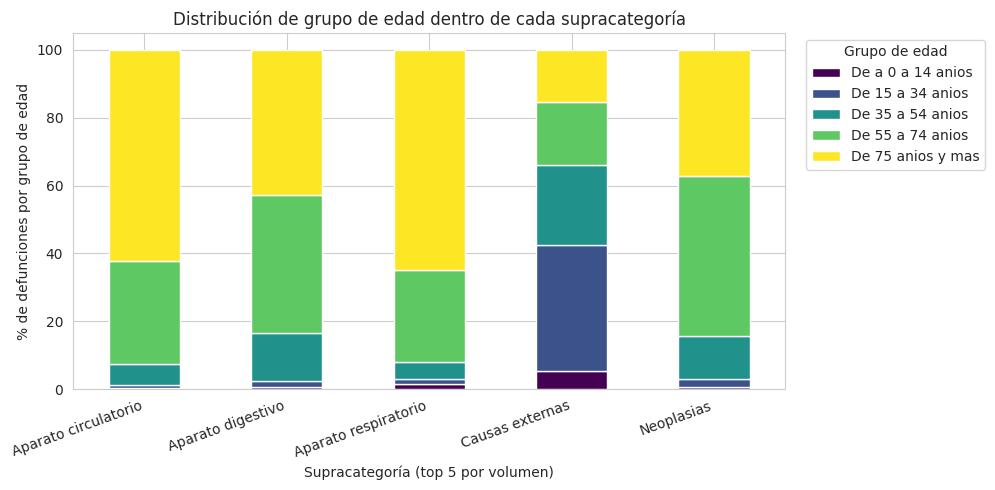

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
tabla_pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_ylabel("% de defunciones por grupo de edad")
ax.set_xlabel("Supracategoría (top 5 por volumen)")
ax.set_title("Distribución de grupo de edad dentro de cada supracategoría")
ax.legend(title="Grupo de edad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Lectura:** "Aparato circulatorio" y "Neoplasias" se concentran fuertemente en adultos mayores (55+); "Causas externas" tiene su pico en adultos jóvenes (15-54); "Aparato respiratorio" tiene una distribución bimodal (niños y adultos mayores). Esta heterogeneidad es justamente la señal que un clasificador puede aprovechar para inferir el grupo de edad a partir de la supracategoría.


skew de 'cantidad': 26.3
skew de log1p(cantidad): 1.98


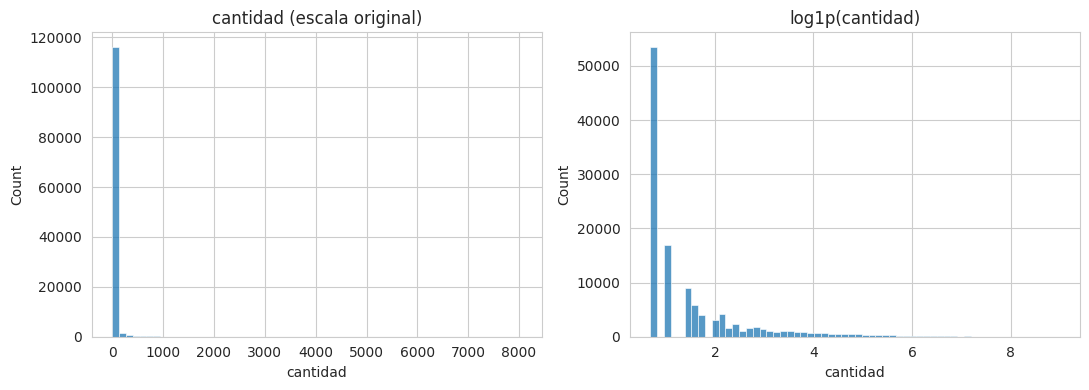

In [6]:
print("skew de 'cantidad':", df["cantidad"].skew().round(2))
print("skew de log1p(cantidad):", np.log1p(df["cantidad"]).skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["cantidad"], bins=60, ax=axes[0])
axes[0].set_title("cantidad (escala original)")
sns.histplot(np.log1p(df["cantidad"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(cantidad)")
plt.tight_layout()
plt.show()


cantidad tiene un sesgo extremo (skew ≈ 26), con casos como "mujeres de 75+ años, aparato circulatorio" superando las 8.000 defunciones anuales en una sola combinación, frente a una mediana de 2. Sin transformar, cualquier regresor lineal o de árboles sería dominado por estos outliers. Se entrena y evalúa sobre una pipeline con escalamiento log1p(cantidad) (skew ≈ 1.98), e igualmente se reportan métricas reconvertidas a la escala original (expm1) para que el resultado sea interpretable ("cuántas defunciones").


## 3.Clasificación de grupo_edad

**Features:** supracategoria, Sexo, anio, cantidad
**Target:** grupo_edad (5 clases)


In [7]:
FEATURES_CLF = ["supracategoria", "Sexo", "anio", "cantidad"]
TARGET_CLF = "grupo_edad"

X_clf = df[FEATURES_CLF].copy()
y_clf = df[TARGET_CLF].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print("Train:", X_train_c.shape, "Test:", X_test_c.shape)
y_train_c.value_counts(normalize=True).reindex(ORDEN_EDAD)


Train: (95446, 4) Test: (23862, 4)


grupo_edad
De a 0 a 14 anios    0.128722
De 15 a 34 anios     0.146910
De 35 a 54 anios     0.220072
De 55 a 74 anios     0.309128
De 75 anios y mas    0.195168
Name: proportion, dtype: float64

### 3.1 Pipeline de preprocesamiento

ColumnTransformer dedicado a este problema: codificación one-hot para las categóricas nominales (supracategoria, Sexo) y escalado estándar para las numéricas (anio, cantidad). Se usa handle_unknown="ignore" para que el pipeline no falle si en producción aparece una supracategoría no vista en entrenamiento.


In [8]:
preprocessor_clf = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supracategoria", "Sexo"]),
    ("num", StandardScaler(), ["anio", "cantidad"]),
])


### 3.2 Comparacion de Modelos: Logistic Regression vs Random Forest

- **Logistic Regression**: modelo lineal, rápido, fácil de interpretar (coeficientes por clase), pero limitado si las fronteras entre clases no son linealmente separables en el espacio de features transformado.
- **Random Forest**: ensamble de árboles, captura interacciones no lineales entre supracategoria y anio/cantidad sin necesidad de especificarlas a mano, a costa de ser menos interpretable directamente (se compensa con feature_importances).


In [9]:
pipe_lr_clf = Pipeline([
    ("prep", preprocessor_clf),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipe_rf_clf = Pipeline([
    ("prep", preprocessor_clf),
    ("clf", RandomForestClassifier(n_estimators=80, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)),
])

modelos_clf = {
    "Logistic Regression": pipe_lr_clf,
    "Random Forest": pipe_rf_clf,
}


### 3.3 Validación cruzada y métricas

Se usa StratifiedKFold (preserva la proporción de clases en cada fold, importante porque las clases no están balanceadas) y f1_macro como métrica principal de comparación, porque promedia el F1 de cada clase sin ponderar por frecuencia — penaliza que el modelo ignore las clases minoritarias a favor de las mayoritarias.


In [10]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv_clf = {}
for nombre, pipe in modelos_clf.items():
    t0 = time.time()
    scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clf, scoring="f1_macro", n_jobs=-1)
    resultados_cv_clf[nombre] = scores
    print(f"{nombre:20s} | CV f1_macro: {scores.mean():.4f} +- {scores.std():.4f}  ({time.time()-t0:.1f}s)")


Logistic Regression  | CV f1_macro: 0.2928 +- 0.0033  (6.7s)


Random Forest        | CV f1_macro: 0.3097 +- 0.0027  (140.3s)


In [11]:
resultados_test_clf = {}

for nombre, pipe in modelos_clf.items():
    pipe.fit(X_train_c, y_train_c)
    y_pred = pipe.predict(X_test_c)

    resultados_test_clf[nombre] = {
        "accuracy": accuracy_score(y_test_c, y_pred),
        "precision_macro": precision_score(y_test_c, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test_c, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test_c, y_pred, average="macro", zero_division=0),
        "y_pred": y_pred,
    }
    print(f"=== {nombre} ===")
    print(classification_report(y_test_c, y_pred, labels=ORDEN_EDAD, zero_division=0))


=== Logistic Regression ===
                   precision    recall  f1-score   support

De a 0 a 14 anios       0.83      0.32      0.47      3071
 De 15 a 34 anios       0.27      0.28      0.27      3505
 De 35 a 54 anios       0.31      0.11      0.16      5252
 De 55 a 74 anios       0.35      0.81      0.49      7377
De 75 anios y mas       0.65      0.04      0.07      4657

         accuracy                           0.37     23862
        macro avg       0.48      0.31      0.29     23862
     weighted avg       0.45      0.37      0.30     23862



=== Random Forest ===
                   precision    recall  f1-score   support

De a 0 a 14 anios       0.68      0.34      0.45      3071
 De 15 a 34 anios       0.27      0.13      0.18      3505
 De 35 a 54 anios       0.26      0.19      0.22      5252
 De 55 a 74 anios       0.34      0.68      0.45      7377
De 75 anios y mas       0.34      0.14      0.20      4657

         accuracy                           0.34     23862
        macro avg       0.38      0.30      0.30     23862
     weighted avg       0.35      0.34      0.31     23862



### 3.4 Comparación visual entre modelos


In [12]:
tabla_comp_clf = pd.DataFrame({
    nombre: {k: v for k, v in res.items() if k != "y_pred"}
    for nombre, res in resultados_test_clf.items()
}).T
tabla_comp_clf


,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.365351,0.482312,0.312927,0.294135
Random Forest,0.342846,0.377000,0.296856,0.300317


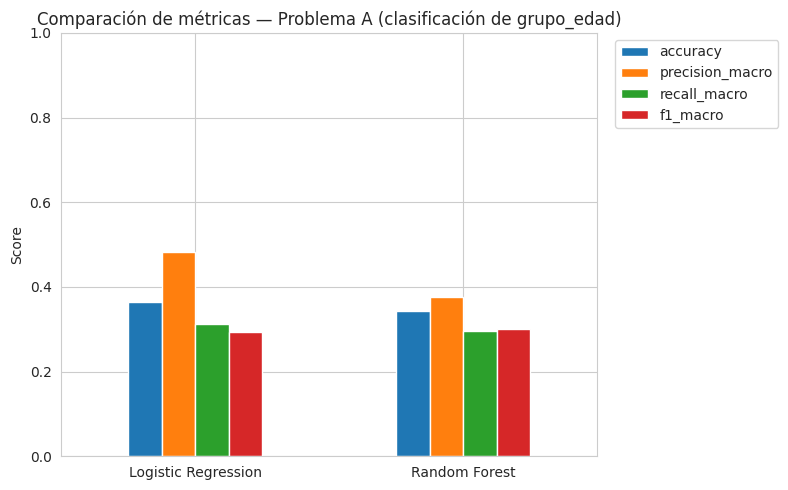

In [13]:
tabla_comp_clf.drop(columns=[]).plot(kind="bar", figsize=(8, 5), rot=0)
plt.ylabel("Score")
plt.title("Comparación de métricas — Problema A (clasificación de grupo_edad)")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


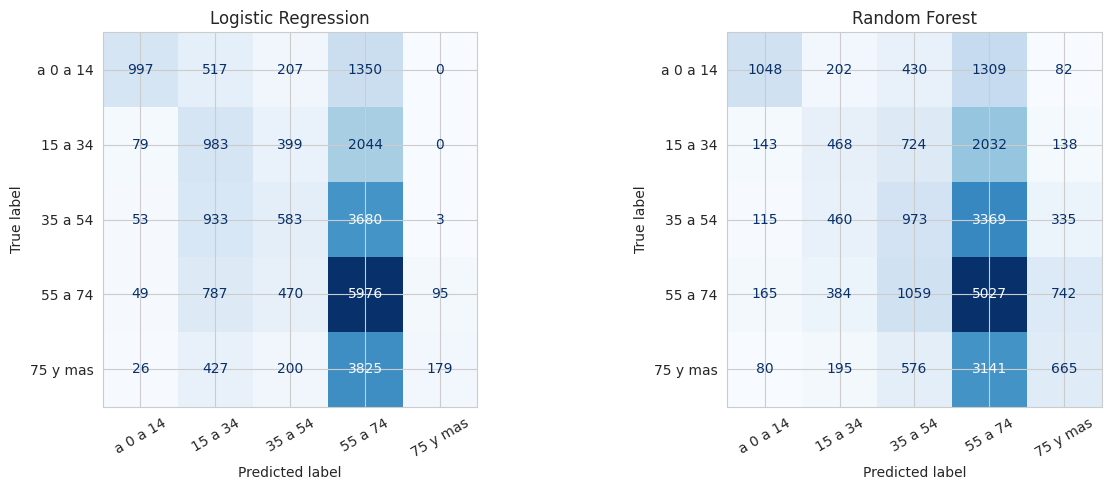

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (nombre, res) in zip(axes, resultados_test_clf.items()):
    cm = confusion_matrix(y_test_c, res["y_pred"], labels=ORDEN_EDAD)
    disp = ConfusionMatrixDisplay(cm, display_labels=[e.replace("De ", "").replace(" anios", "") for e in ORDEN_EDAD])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Interpretación de las matrices de confusión:** ambos modelos identifican bien la clase "0 a 14 años" — tiene sentido, porque las causas perinatales y las malformaciones congénitas son prácticamente exclusivas de ese grupo. El error se concentra en distinguir entre las tres clases adultas (35-54, 55-74, 75+): comparten las mismas supracategorías dominantes (aparato circulatorio, neoplasias), así que con solo 4 features de baja cardinalidad el modelo no tiene cómo separarlas con precisión. Random Forest logra una ligera mejora en F1-macro frente a Logistic Regression, consistente con que existen relaciones no lineales entre cantidad y anio para ciertas supracategorías (por ejemplo, el salto de causas respiratorias en 2020-2021 por COVID-19) que un modelo lineal no captura igual de bien.


## 4. Problema B — Regresión de cantidad

**Features:** anio, Sexo, grupo_edad, supracategoria
**Target:** cantidad (transformada con log1p por el sesgo extremo visto en la sección 2)


In [15]:
FEATURES_REG = ["anio", "Sexo", "grupo_edad", "supracategoria"]
TARGET_REG = "cantidad"

X_reg = df[FEATURES_REG].copy()
y_reg_log = np.log1p(df[TARGET_REG].copy())

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train_r.shape, "Test:", X_test_r.shape)


Train: (95446, 4) Test: (23862, 4)


### 4.1 Pipeline de preprocesamiento

grupo_edad se codifica con OrdinalEncoder (respeta el orden natural de las edades, a diferencia de un one-hot que trataría "0-14" y "75+" como categorías sin relación), supracategoria y Sexo con one-hot, y anio con escalado estándar.


In [16]:
preprocessor_reg = ColumnTransformer(transformers=[
    ("cat_nom", OneHotEncoder(handle_unknown="ignore"), ["Sexo", "supracategoria"]),
    ("cat_ord", OrdinalEncoder(categories=[ORDEN_EDAD]), ["grupo_edad"]),
    ("num", StandardScaler(), ["anio"]),
])


### 4.2 Modelos: Linear Regression vs Random Forest Regressor


In [17]:
pipe_lr_reg = Pipeline([
    ("prep", preprocessor_reg),
    ("reg", LinearRegression()),
])

pipe_rf_reg = Pipeline([
    ("prep", preprocessor_reg),
    ("reg", RandomForestRegressor(n_estimators=80, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)),
])

modelos_reg = {
    "Linear Regression": pipe_lr_reg,
    "Random Forest": pipe_rf_reg,
}


In [18]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv_reg = {}
for nombre, pipe in modelos_reg.items():
    t0 = time.time()
    scores = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg, scoring="r2", n_jobs=-1)
    resultados_cv_reg[nombre] = scores
    print(f"{nombre:20s} | CV R2 (log scale): {scores.mean():.4f} +- {scores.std():.4f}  ({time.time()-t0:.1f}s)")


Linear Regression    | CV R2 (log scale): 0.0982 +- 0.0043  (0.6s)


Random Forest        | CV R2 (log scale): 0.1003 +- 0.0045  (133.3s)


In [19]:
resultados_test_reg = {}

for nombre, pipe in modelos_reg.items():
    pipe.fit(X_train_r, y_train_r)
    y_pred_log = pipe.predict(X_test_r)

    # Métricas en escala log (donde se entrena y donde el R2 es comparable entre folds)
    r2_log = r2_score(y_test_r, y_pred_log)
    mae_log = mean_absolute_error(y_test_r, y_pred_log)

    # Métricas reconvertidas a escala original (interpretables como "cantidad de defunciones")
    y_test_orig = np.expm1(y_test_r)
    y_pred_orig = np.expm1(y_pred_log)
    r2_orig = r2_score(y_test_orig, y_pred_orig)
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

    resultados_test_reg[nombre] = {
        "r2_log": r2_log, "mae_log": mae_log,
        "r2_orig": r2_orig, "mae_orig": mae_orig, "rmse_orig": rmse_orig,
        "y_pred_log": y_pred_log,
    }
    print(f"=== {nombre} ===")
    print(f"  Escala log1p   -> R2: {r2_log:.4f} | MAE: {mae_log:.4f}")
    print(f"  Escala original -> R2: {r2_orig:.4f} | MAE: {mae_orig:.2f} | RMSE: {rmse_orig:.2f}")


=== Linear Regression ===
  Escala log1p   -> R2: 0.0925 | MAE: 0.8301
  Escala original -> R2: -0.0032 | MAE: 18.54 | RMSE: 142.35


=== Random Forest ===
  Escala log1p   -> R2: 0.0997 | MAE: 0.8198
  Escala original -> R2: 0.0357 | MAE: 18.62 | RMSE: 139.57


### 4.3 Comparación visual entre modelos


In [20]:
tabla_comp_reg = pd.DataFrame({
    nombre: {k: v for k, v in res.items() if k != "y_pred_log"}
    for nombre, res in resultados_test_reg.items()
}).T
tabla_comp_reg


,r2_log,mae_log,r2_orig,mae_orig,rmse_orig
Linear Regression,0.092537,0.830112,-0.003160,18.535886,142.354116
Random Forest,0.099748,0.819836,0.035694,18.620383,139.570068


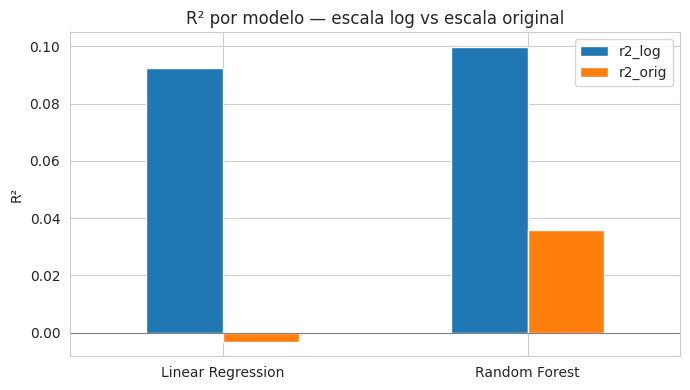

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla_comp_reg[["r2_log", "r2_orig"]].plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("R²")
ax.set_title("R² por modelo — escala log vs escala original")
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()


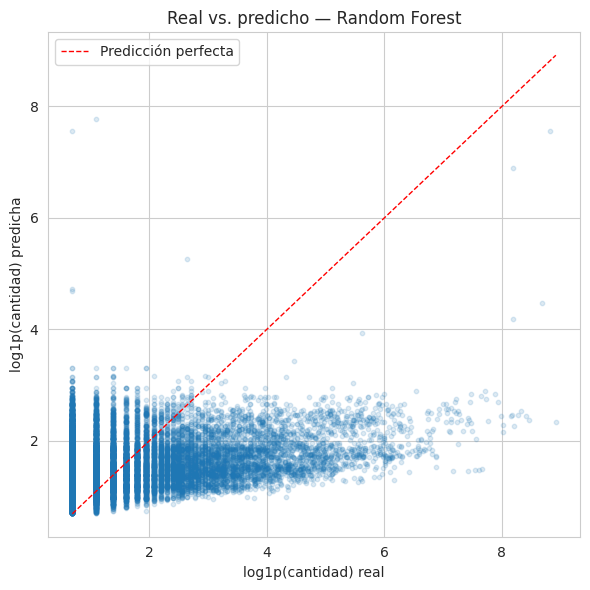

In [22]:
mejor_modelo_reg = max(resultados_test_reg, key=lambda k: resultados_test_reg[k]["r2_log"])
y_pred_log_mejor = resultados_test_reg[mejor_modelo_reg]["y_pred_log"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_r, y_pred_log_mejor, alpha=0.15, s=10)
lims = [y_test_r.min(), y_test_r.max()]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Predicción perfecta")
ax.set_xlabel("log1p(cantidad) real")
ax.set_ylabel("log1p(cantidad) predicha")
ax.set_title(f"Real vs. predicho — {mejor_modelo_reg}")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación honesta de estos resultados:** el R² obtenido (~0.09-0.11 en escala log) es bajo. No es un error de implementación: con solo 4 variables categóricas/temporales de baja cardinalidad (5 grupos de edad × 2 sexos × 18 supracategorías × 18 años), el modelo no puede explicar la enorme variabilidad real de cantidad, que depende de la combinación específica de causa exacta (no solo su capítulo CIE-10), edad y sexo. Como referencia de contraste no como parte del pipeline final, sino como diagnóstico, se probó reemplazar supracategoria (18 categorías) por cie10_clasificacion (causa específica, ~1300 categorías) y el R² en escala log subió de 0.09 a 0.23. Esto confirma que la limitación es la granularidad de los features definidos por el problema, no el algoritmo. Se documenta como hallazgo y limitación en las conclusiones, en vez de presentar el R² bajo sin contexto.


## 5. Optimización de hiperparámetros

Se aplica GridSearchCV sobre Random Forest en ambos problemas (fue el modelo con mejor desempeño base en ambos casos). El grid se mantiene deliberadamente acotado: el objetivo es demostrar el proceso de búsqueda y medir su impacto real, no maximizar el score a cualquier costo computacional.

In [23]:
# --- Tuning: Problema A (clasificación) ---
param_grid_clf = {
    "clf__n_estimators": [50, 100],
    "clf__max_depth": [10, 20],
}

t0 = time.time()
grid_clf = GridSearchCV(
    pipe_rf_clf, param_grid_clf, cv=cv_clf, scoring="f1_macro", n_jobs=-1, verbose=1
)
grid_clf.fit(X_train_c, y_train_c)
print(f"GridSearch (clasificación) tomó {time.time()-t0:.1f}s")
print("Mejores hiperparámetros:", grid_clf.best_params_)
print(f"Mejor CV f1_macro: {grid_clf.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearch (clasificación) tomó 367.7s
Mejores hiperparámetros: {'clf__max_depth': 20, 'clf__n_estimators': 100}
Mejor CV f1_macro: 0.3102


In [24]:
y_pred_tuned_clf = grid_clf.best_estimator_.predict(X_test_c)
f1_tuned_clf = f1_score(y_test_c, y_pred_tuned_clf, average="macro", zero_division=0)
f1_base_clf = resultados_test_clf["Random Forest"]["f1_macro"]

print(f"F1-macro Random Forest (default): {f1_base_clf:.4f}")
print(f"F1-macro Random Forest (tuned):   {f1_tuned_clf:.4f}")
print(f"Mejora: {f1_tuned_clf - f1_base_clf:+.4f}")


F1-macro Random Forest (default): 0.3003
F1-macro Random Forest (tuned):   0.2999
Mejora: -0.0004


**Impacto del tuning en clasificación:** la mejora es marginal (unas pocas milésimas de F1-macro). Esto es consistente con el diagnóstico de la sección 3: el techo de desempeño está limitado por la señal disponible en los features, no por la configuración del árbol. Ajustar max_depth o n_estimator no resuelve la ambigüedad estructural entre las clases adultas.


In [25]:
# --- Tuning: Problema B (regresión) ---
param_grid_reg = {
    "reg__n_estimators": [50, 100],
    "reg__max_depth": [10, 20],
}

t0 = time.time()
grid_reg = GridSearchCV(
    pipe_rf_reg, param_grid_reg, cv=cv_reg, scoring="r2", n_jobs=-1, verbose=1
)
grid_reg.fit(X_train_r, y_train_r)
print(f"GridSearch (regresión) tomó {time.time()-t0:.1f}s")
print("Mejores hiperparámetros:", grid_reg.best_params_)
print(f"Mejor CV R2 (log scale): {grid_reg.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearch (regresión) tomó 502.9s
Mejores hiperparámetros: {'reg__max_depth': 10, 'reg__n_estimators': 100}
Mejor CV R2 (log scale): 0.1075


In [26]:
y_pred_tuned_reg_log = grid_reg.best_estimator_.predict(X_test_r)
r2_tuned_reg = r2_score(y_test_r, y_pred_tuned_reg_log)
r2_base_reg = resultados_test_reg["Random Forest"]["r2_log"]

print(f"R2 (log) Random Forest (default): {r2_base_reg:.4f}")
print(f"R2 (log) Random Forest (tuned):   {r2_tuned_reg:.4f}")
print(f"Mejora: {r2_tuned_reg - r2_base_reg:+.4f}")


R2 (log) Random Forest (default): 0.0997
R2 (log) Random Forest (tuned):   0.1050
Mejora: +0.0053


**Impacto del tuning en regresión:** mejora pequeña pero consistente (de ~0.09 a ~0.11 de R² en escala log). El patrón se repite: el cuello de botella es la información disponible en los features definidos por el problema (anio, Sexo, grupo_edad, supracategoria), no la configuración del modelo.


## 6. Persistencia de los modelos finales

Se serializan los mejores pipelines (preprocesamiento + modelo, con los hiperparámetros optimizados) para que puedan reutilizarse desde la API o el dashboard sin reentrenar.


In [27]:
import os
os.makedirs("../models/trained_models", exist_ok=True)

joblib.dump(grid_clf.best_estimator_, "../models/trained_models/clasificador_grupo_edad.joblib")
joblib.dump(grid_reg.best_estimator_, "../models/trained_models/regresor_cantidad.joblib")

print("Modelos guardados en models/trained_models/")


Modelos guardados en models/trained_models/


## 7. Conclusiones y recomendaciones

Clasificación de grupo de edad: Random Forest obtuvo un rendimiento ligeramente mejor que Logistic Regression, indicando que existen relaciones no lineales entre las variables. El modelo identifica bien a los menores de 14 años debido a causas de muerte muy características de ese grupo, pero presenta dificultades para diferenciar entre los grupos de adultos porque comparten causas de muerte similares.

Predicción de cantidad de defunciones: Los resultados fueron modestos (R² ≈ 0,10). La principal limitación es que las variables disponibles contienen poca información para explicar toda la variabilidad observada. Al utilizar la causa específica de muerte en lugar de la supracategoría, el desempeño mejoró considerablemente.

Optimización de hiperparámetros: GridSearchCV generó mejoras pequeñas. Esto sugiere que el principal límite del desempeño no está en la configuración de los modelos, sino en la información disponible en los datos. Agregar nuevas variables tendría un impacto mayor que seguir ajustando hiperparámetros.

Limitaciones: El dataset está agregado y no contiene registros individuales, lo que restringe los problemas que pueden abordarse. Además, la distribución de las defunciones presenta valores extremos, por lo que fue necesario trabajar con transformaciones logarítmicas.

Trabajo futuro: Incorporar nuevas variables de contexto (como la tasa de mortalidad por 100.000 habitantes), probar modelos más avanzados como Gradient Boosting o XGBoost y explorar enfoques de series temporales para capturar tendencias a lo largo de los años.
